# Notebook 1 — Train Ticket
## Analyse des données d'observabilité : normal vs anomalies

**Système** : Train Ticket — 41 microservices Java Spring Boot  
**Dataset** : Nezha (Yu et al., FSE 2023)  
**Dates** : 29 et 30 janvier 2023  
**Modalités** : Logs · Métriques · Traces  

---

### Objectif

Ce notebook explore les données d'observabilité du système Train Ticket
en deux phases :

1. **Données normales** (`construct_data`) — comportement de référence  
2. **Données avec pannes** (`rca_data`) — 45 pannes injectées délibérément

L'objectif est de comprendre visuellement ce qui change dans les logs,
métriques et traces pendant une panne — avant de coder les algorithmes
de détection.

---

### Structure

| Section | Contenu |
|---------|---------|
| 1. Configuration | Imports, chemins, paramètres |
| 2. Données normales | Logs, métriques, traces sans panne |
| 3. Vérité terrain | Les 45 pannes — quand, où, quel type |
| 4. Données avec pannes | Logs, métriques, traces pendant une panne |
| 5. Comparaison | Normal vs anormal côte à côte |

In [1]:
# ── Imports
import os, json, warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime, timedelta
import re
warnings.filterwarnings('ignore')

# ── Chemins
PROJET    = Path('/home/eunice/Bureau/Train_ticket/projet')
NORMAL    = PROJET / 'data/normal'
ANOMALIES = PROJET / 'data/anomalies'
FIGURES   = PROJET / 'figures/TrainTicket'
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Paramètres Train Ticket
DATES     = ['2023-01-29', '2023-01-30']
FAULT_DUR = 3  # minutes — Yu et al. FSE 2023

# ── Palette de couleurs par type de panne
PALETTE = {
    'return'        : '#378ADD',
    'exception'     : '#E24B4A',
    'network_delay' : '#EF9F27',
    'cpu_contention': '#1D9E75',
    'none'          : '#888780',
}

# ── Vérification
assert NORMAL.exists(),    f"Introuvable : {NORMAL}"
assert ANOMALIES.exists(), f"Introuvable : {ANOMALIES}"

print("✓ Configuration OK")
print(f"  Python     : {os.sys.version.split()[0]}")
print(f"  Pandas     : {pd.__version__}")
print(f"  Matplotlib : {plt.matplotlib.__version__}")
print(f"  Normal     : {NORMAL}")
print(f"  Anomalies  : {ANOMALIES}")
print(f"  Figures    : {FIGURES}")

✓ Configuration OK
  Python     : 3.12.3
  Pandas     : 3.0.3
  Matplotlib : 3.10.9
  Normal     : /home/eunice/Bureau/Train_ticket/projet/data/normal
  Anomalies  : /home/eunice/Bureau/Train_ticket/projet/data/anomalies
  Figures    : /home/eunice/Bureau/Train_ticket/projet/figures/TrainTicket


## 2. Données normales — `construct_data`

Ces données ont été collectées **sans aucune panne injectée**.  
Elles représentent le comportement de référence de Train Ticket —  
ce à quoi ressemblent les logs, métriques et traces quand tout va bien.

Chaque minute collectée contient 3 fichiers :
- `log/HH_MM_log.csv` — messages applicatifs des 41 services
- `metric/<service>_metric.csv` — CPU, RAM, latence par pod
- `trace/HH_MM_trace.csv` — appels distribués entre services

### Pourquoi commencer par le normal ?

Un détecteur d'anomalies apprend d'abord ce qu'est le comportement normal.  
Sans cette référence, il est impossible de dire si quelque chose est anormal.

In [2]:
# Vérifier ce qui est disponible dans les données normales
for date in DATES:
    chemin = NORMAL / date
    print(f"\n=== {date} ===")
    for dossier in sorted(chemin.iterdir()):
        nb = len(list(dossier.glob('*')))
        print(f"  {dossier.name:<10} → {nb} fichiers")


=== 2023-01-29 ===
  log        → 1 fichiers
  metric     → 47 fichiers
  trace      → 1 fichiers
  traceid    → 1 fichiers

=== 2023-01-30 ===
  log        → 1 fichiers
  metric     → 47 fichiers
  trace      → 1 fichiers
  traceid    → 1 fichiers


### 2.1 Logs normaux

On charge le fichier de logs de la journée du 29 janvier.  
Chaque ligne représente un message applicatif émis par un service.  
Les colonnes clés sont :
- `Timestamp` — heure exacte du message
- `PodName` — service qui a émis le message
- `TraceID` — identifiant de la requête utilisateur
- `Log` — contenu du message

In [3]:
# Charger le fichier de logs normaux du 29 janvier
log_file = list((NORMAL / '2023-01-29/log').glob('*.csv'))[0]
df_log_normal = pd.read_csv(log_file)

# Extraire le nom du service depuis le PodName
df_log_normal['service'] = df_log_normal['PodName'].apply(
    lambda x: str(x).rsplit('-', 2)[0]
)

# Extraire le niveau de log depuis la colonne Log
def extraire_niveau(log_str):
    match = re.search(r'\b(INFO|ERROR|WARN|DEBUG)\b', str(log_str))
    return match.group(1) if match else 'INCONNU'

df_log_normal['niveau'] = df_log_normal['Log'].apply(extraire_niveau)

print(f"Fichier  : {log_file.name}")
print(f"Lignes   : {len(df_log_normal)}")
print(f"Services : {df_log_normal['service'].nunique()}")
print()
print("Niveaux de log :")
print(df_log_normal['niveau'].value_counts().to_string())

Fichier  : 08_50_log.csv
Lignes   : 2489
Services : 22

Niveaux de log :
niveau
INFO     2350
WARN      112
ERROR      27


### Visualisation des logs normaux

3 graphiques pour comprendre le comportement normal :
- Répartition des niveaux de log (INFO / WARN / ERROR)
- Les services les plus actifs
- Le nombre de requêtes uniques par service

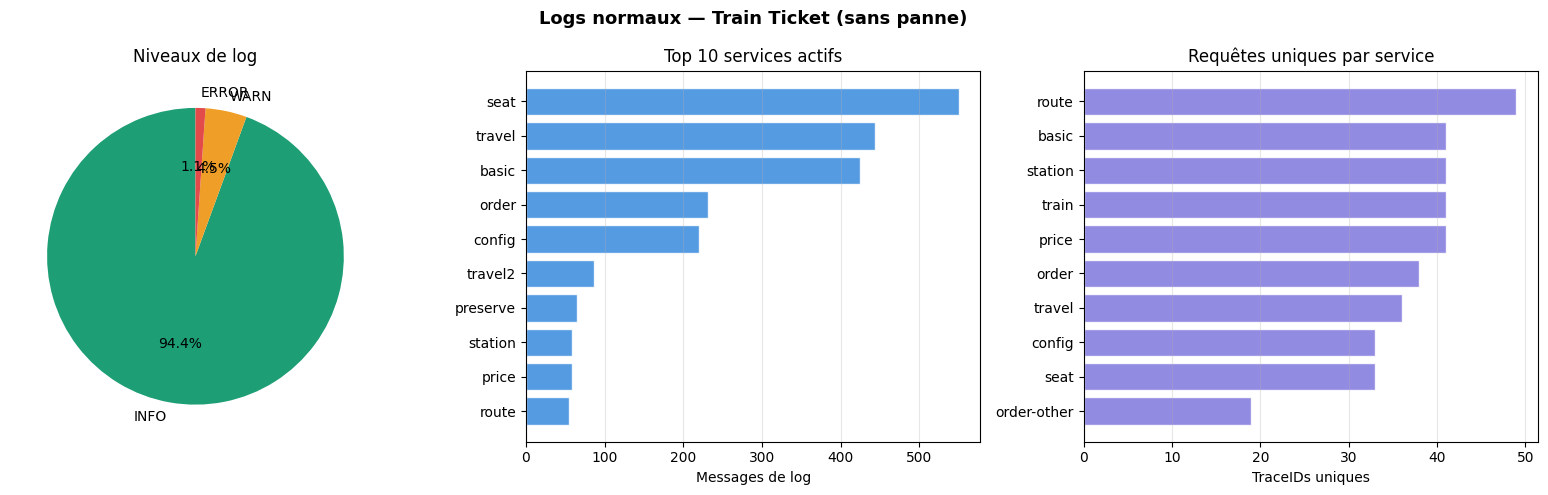

Sauvegardé : 01_logs_normaux.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Logs normaux — Train Ticket (sans panne)',
             fontsize=13, fontweight='bold')

# ── Graphique 1 : Niveaux de log
niveaux = df_log_normal['niveau'].value_counts()
couleurs = {
    'INFO'   : '#1D9E75',
    'WARN'   : '#EF9F27',
    'ERROR'  : '#E24B4A',
    'INCONNU': '#888780'
}
axes[0].pie(
    niveaux.values,
    labels=niveaux.index,
    colors=[couleurs.get(n, '#888') for n in niveaux.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Niveaux de log')

# ── Graphique 2 : Top 10 services les plus actifs
top10 = df_log_normal['service'].value_counts().head(10)
noms  = [s.replace('ts-','').replace('-service','') for s in top10.index]
axes[1].barh(noms[::-1], top10.values[::-1],
             color='#378ADD', alpha=0.85, edgecolor='white')
axes[1].set_title('Top 10 services actifs')
axes[1].set_xlabel('Messages de log')
axes[1].grid(axis='x', alpha=0.3)

# ── Graphique 3 : Requêtes uniques par service
requetes = df_log_normal.groupby('service')['TraceID'].nunique()
requetes = requetes.sort_values(ascending=False).head(10)
noms2    = [s.replace('ts-','').replace('-service','') for s in requetes.index]
axes[2].barh(noms2[::-1], requetes.values[::-1],
             color='#7F77DD', alpha=0.85, edgecolor='white')
axes[2].set_title('Requêtes uniques par service')
axes[2].set_xlabel('TraceIDs uniques')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '01_logs_normaux.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 01_logs_normaux.png")

### 2.2 Métriques normales

Les métriques sont collectées **par pod** toutes les minutes.  
Chaque fichier correspond à un service précis et contient 21 colonnes :

- **CPU** : consommation et taux d'utilisation
- **Mémoire** : utilisation en Mo et en pourcentage  
- **Réseau** : octets reçus et transmis
- **Latence** : percentiles P90, P95, P99 (client et serveur)
- **Santé** : charge de travail et taux de succès

Ces valeurs en phase normale constituent notre **référence**.  
Tout écart significatif par rapport à ces valeurs sera considéré  
comme un signal d'anomalie.

In [5]:
# Lister tous les pods disponibles
metric_dir = NORMAL / '2023-01-29/metric'
fichiers   = sorted(metric_dir.glob('*_metric.csv'))

print(f"Pods disponibles : {len(fichiers)}")
print()

# Charger le service auth comme exemple
auth_file      = next(f for f in fichiers if 'ts-auth-service' in f.name)
df_metric_norm = pd.read_csv(auth_file)

# Convertir le timestamp en datetime lisible
df_metric_norm['datetime'] = pd.to_datetime(
    df_metric_norm['TimeStamp'], unit='s', utc=True
)

# Convertir les colonnes numériques
for col in df_metric_norm.columns:
    if col not in ['Time', 'PodName', 'datetime']:
        df_metric_norm[col] = pd.to_numeric(
            df_metric_norm[col].replace('NaN', float('nan')),
            errors='coerce'
        )

print(f"Service : {auth_file.stem.rsplit('-',2)[0]}")
print(f"Lignes  : {len(df_metric_norm)}")
print()
print("Statistiques des métriques clés :")
cols_cles = [
    'CpuUsageRate(%)',
    'MemoryUsageRate(%)',
    'PodServerLatencyP99(s)',
    'PodSuccessRate(%)'
]
print(df_metric_norm[cols_cles].describe().round(4).to_string())

Pods disponibles : 46

Service : ts-auth-service
Lignes  : 919

Statistiques des métriques clés :
       CpuUsageRate(%)  MemoryUsageRate(%)  PodServerLatencyP99(s)  PodSuccessRate(%)
count         919.0000            919.0000                613.0000              919.0
mean            1.7243             23.0784                  0.2609                0.0
std             0.9998              0.4475                  0.0791                0.0
min             0.0000             22.1018                  0.0099                0.0
25%             0.9910             22.6188                  0.2485                0.0
50%             1.5778             23.2801                  0.2485                0.0
75%             2.3172             23.4127                  0.2485                0.0
max             6.2706             23.8033                  0.9900                0.0


### Visualisation des métriques normales

On visualise 4 métriques clés de `ts-auth-service` en phase normale :

- **CPU** — consommation processeur en pourcentage
- **Mémoire** — utilisation RAM en pourcentage
- **Latence P99** — 99% des requêtes sont traitées en moins de X secondes
- **Réseau** — octets reçus par le service

La ligne pointillée représente la **moyenne** — c'est notre valeur de référence.  
Tout ce qui s'écarte fortement de cette ligne sera suspect lors de l'analyse des pannes.

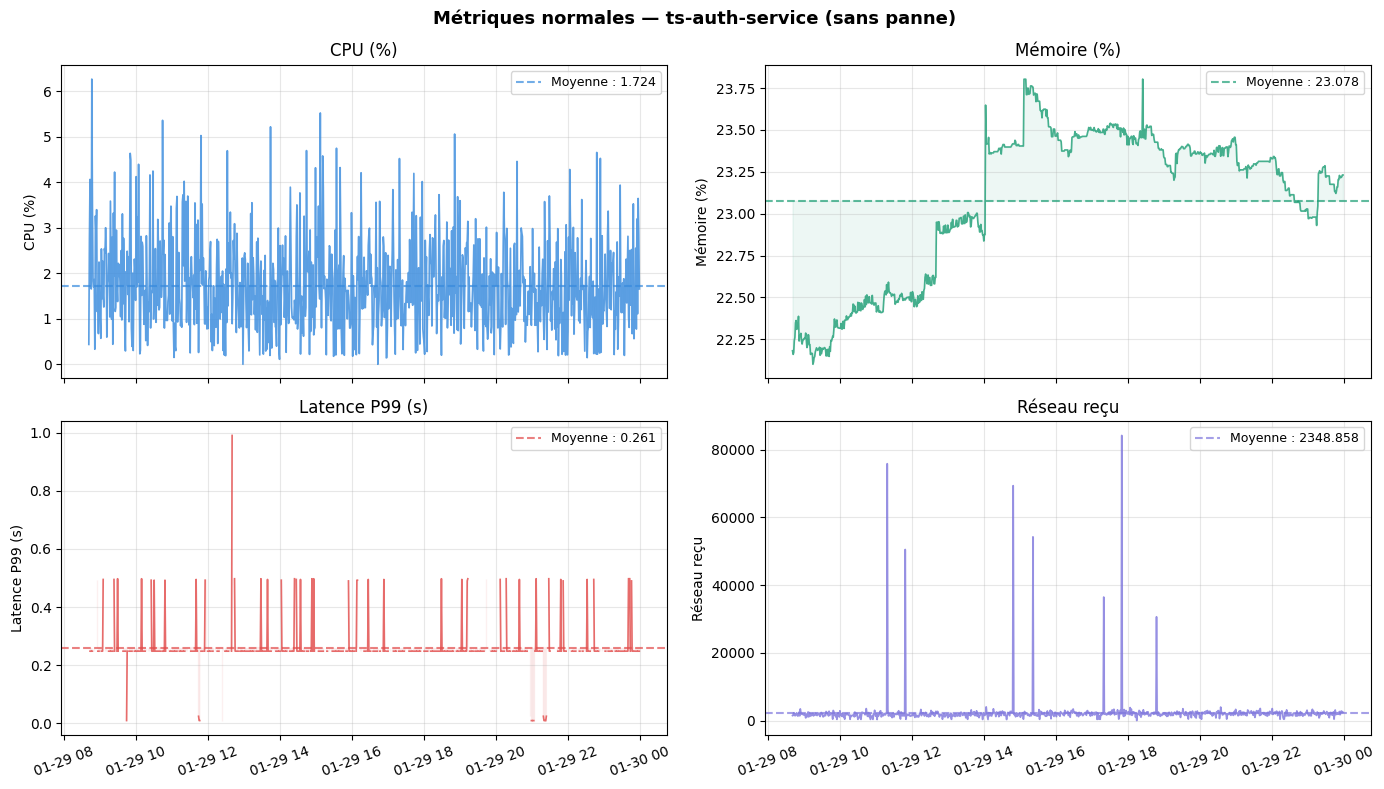

Sauvegardé : 02_metriques_normales.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle('Métriques normales — ts-auth-service (sans panne)',
             fontsize=13, fontweight='bold')

metriques = [
    ('CpuUsageRate(%)',        'CPU (%)',           '#378ADD'),
    ('MemoryUsageRate(%)',     'Mémoire (%)',        '#1D9E75'),
    ('PodServerLatencyP99(s)', 'Latence P99 (s)',   '#E24B4A'),
    ('NetworkReceiveBytes',    'Réseau reçu',       '#7F77DD'),
]

for ax, (col, label, color) in zip(axes.flatten(), metriques):
    vals = df_metric_norm[col]
    ax.plot(df_metric_norm['datetime'], vals,
            color=color, linewidth=1.2, alpha=0.8)
    ax.axhline(vals.mean(), color=color, linewidth=1.5,
               linestyle='--', alpha=0.7,
               label=f'Moyenne : {vals.mean():.3f}')
    ax.fill_between(df_metric_norm['datetime'], vals,
                    vals.mean(), alpha=0.08, color=color)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[1][0].tick_params(axis='x', rotation=20)
axes[1][1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES / '02_metriques_normales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 02_metriques_normales.png")

### 2.3 Traces normales

Une trace représente le **chemin complet d'une requête** à travers les services.  
Chaque ligne est un **span** — une action précise dans un service donné.

Les spans du même `TraceID` forment l'arbre d'une requête complète.  
En phase normale, cet arbre est cohérent et les durées sont prévisibles.

Colonnes clés :
- `TraceID` — identifiant unique de la requête
- `ParentID` — action parente (reconstruit l'arbre)
- `Duration` — durée en nanosecondes
- `PodName` — service qui a exécuté cette action

In [7]:
# Charger le fichier de traces normales
trace_file    = list((NORMAL / '2023-01-29/trace').glob('*.csv'))[0]
df_trace_norm = pd.read_csv(trace_file)

# Convertir la durée en millisecondes
df_trace_norm['duration_ms'] = pd.to_numeric(
    df_trace_norm['Duration'], errors='coerce'
) / 1e6

# Extraire le nom du service
df_trace_norm['service'] = df_trace_norm['PodName'].apply(
    lambda x: str(x).rsplit('-', 2)[0]
)

print(f"Fichier  : {trace_file.name}")
print(f"Spans    : {len(df_trace_norm)}")
print(f"Traces   : {df_trace_norm['TraceID'].nunique()} requêtes uniques")
print(f"Services : {df_trace_norm['service'].nunique()}")
print()
print("Statistiques de durée (ms) :")
print(df_trace_norm['duration_ms'].describe().round(3).to_string())

Fichier  : 08_50_trace.csv
Spans    : 4890
Traces   : 71 requêtes uniques
Services : 25

Statistiques de durée (ms) :
count    4890.000
mean        0.025
std         0.077
min         0.000
25%         0.001
50%         0.003
75%         0.010
max         0.840


### Visualisation des traces normales

2 graphiques pour comprendre les traces normales :
- Nombre de spans par service — qui est le plus sollicité ?
- Distribution des durées — quelle est la latence normale ?

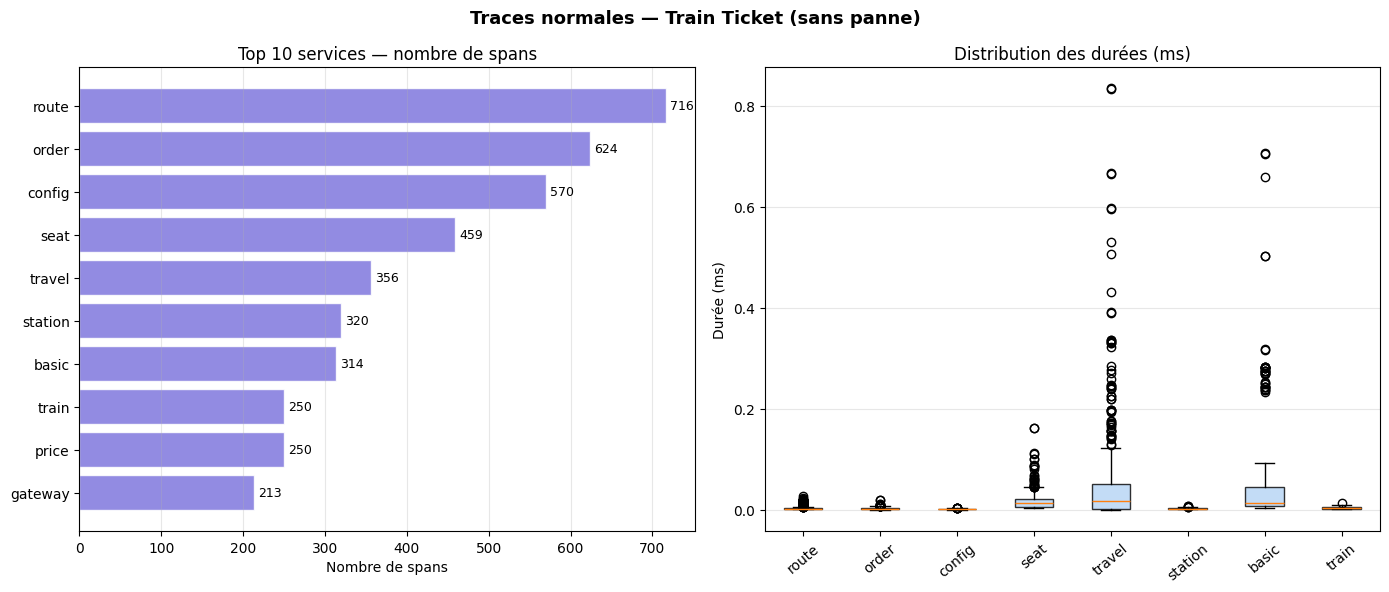

Sauvegardé : 03_traces_normales.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Traces normales — Train Ticket (sans panne)',
             fontsize=13, fontweight='bold')

# ── Graphique 1 : Spans par service
top_svcs  = df_trace_norm['service'].value_counts().head(10)
noms      = [s.replace('ts-','').replace('-service','') 
             for s in top_svcs.index]
axes[0].barh(noms[::-1], top_svcs.values[::-1],
             color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 10 services — nombre de spans')
axes[0].set_xlabel('Nombre de spans')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_svcs.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# ── Graphique 2 : Distribution des durées
top8     = df_trace_norm['service'].value_counts().head(8).index.tolist()
df_top   = df_trace_norm[df_trace_norm['service'].isin(top8)]
data_box = [df_top[df_top['service'] == s]['duration_ms'].dropna().values
            for s in top8]
noms2    = [s.replace('ts-','').replace('-service','')[:12] 
            for s in top8]
bp = axes[1].boxplot(data_box, labels=noms2, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#B5D4F4')
    patch.set_alpha(0.8)
axes[1].set_title('Distribution des durées (ms)')
axes[1].set_ylabel('Durée (ms)')
axes[1].tick_params(axis='x', rotation=40)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '03_traces_normales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 03_traces_normales.png")

## 3. Vérité terrain — `fault_list.json`

La vérité terrain est le **carnet de bord** des chercheurs de Nezha.  
Pour chaque panne injectée, il indique :

- **inject_time** — quand la panne a été injectée (timestamp précis)
- **inject_pod** — quel pod a été ciblé
- **inject_type** — quel type de panne

Cette information n'existe pas dans un vrai système en production.  
On l'utilise uniquement pour **évaluer** nos algorithmes de détection —  
pour savoir s'ils ont correctement identifié les bonnes pannes.

Les 4 types de pannes injectées :
- `return` — la fonction retourne une valeur incorrecte
- `exception` — la fonction lève une exception
- `network_delay` — latence réseau artificielle
- `cpu_contention` — contention CPU artificielle

In [9]:
# Charger et aplatir les fault_list des 2 jours
rows = []
for date in DATES:
    chemin = ANOMALIES / date / f'{date}-fault_list.json'
    with open(chemin) as f:
        data = json.load(f)
    for heure, pannes in data.items():
        for panne in pannes:
            pod     = panne['inject_pod']
            service = pod.rsplit('-', 2)[0]
            rows.append({
                'date'       : date,
                'inject_time': panne['inject_time'],
                'fault_type' : panne['inject_type'],
                'service'    : service,
                'pod'        : pod,
            })

faults = pd.DataFrame(rows)
faults['inject_dt'] = pd.to_datetime(faults['inject_time'])

print(f"Total pannes  : {len(faults)}")
print(f"Types uniques : {sorted(faults['fault_type'].unique())}")
print()
faults

Total pannes  : 45
Types uniques : ['cpu_contention', 'exception', 'network_delay', 'return']



,date,inject_time,fault_type,service,pod,inject_dt
0,2023-01-29,2023-01-29 08:43:04,return,ts-contacts-service,ts-contacts-service-866bd68c97-xcqfx,2023-01-29 08:43:04
1,2023-01-29,2023-01-29 08:52:06,return,ts-contacts-service,ts-contacts-service-866bd68c97-xcqfx,2023-01-29 08:52:06
2,2023-01-29,2023-01-29 08:58:16,return,ts-contacts-service,ts-contacts-service-866bd68c97-xcqfx,2023-01-29 08:58:16
3,2023-01-29,2023-01-29 09:03:53,return,ts-basic-service,ts-basic-service-5dc8d4f9fd-46997,2023-01-29 09:03:53
4,2023-01-29,2023-01-29 09:12:56,return,ts-basic-service,ts-basic-service-5dc8d4f9fd-46997,2023-01-29 09:12:56
5,2023-01-29,2023-01-29 09:21:39,return,ts-basic-service,ts-basic-service-5dc8d4f9fd-46997,2023-01-29 09:21:39
6,2023-01-29,2023-01-29 09:25:39,exception,ts-basic-service,ts-basic-service-5dc8d4f9fd-46997,2023-01-29 09:25:39
7,2023-01-29,2023-01-29 09:30:09,return,ts-food-service,ts-food-service-f5756978c-k8vqf,2023-01-29 09:30:09
8,2023-01-29,2023-01-29 09:34:19,return,ts-food-service,ts-food-service-f5756978c-k8vqf,2023-01-29 09:34:19
9,2023-01-29,2023-01-29 09:42:26,return,ts-verification-code-service,ts-verification-code-service-7b6dc75c45-2z9p2,2023-01-29 09:42:26


### Visualisation de la vérité terrain

3 graphiques pour comprendre la distribution des 45 pannes :
- Répartition par type de panne
- Répartition par service ciblé
- Timeline — quand chaque panne a été injectée

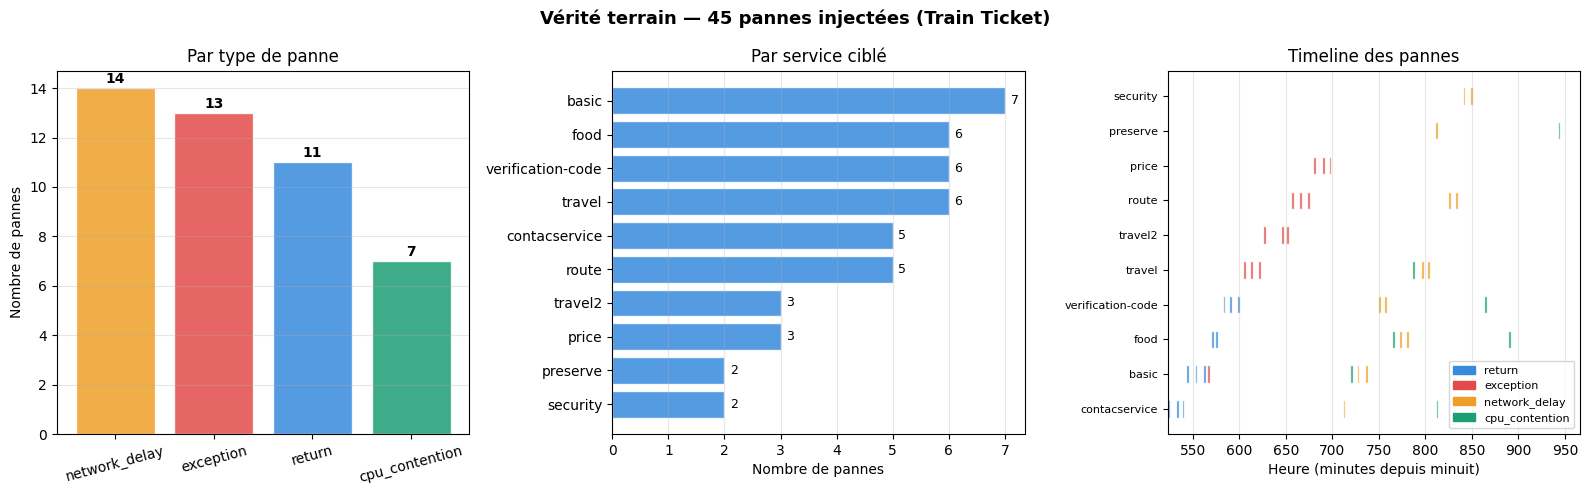

Sauvegardé : 04_verite_terrain.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Vérité terrain — 45 pannes injectées (Train Ticket)',
             fontsize=13, fontweight='bold')

# ── Graphique 1 : Par type de panne
type_counts = faults['fault_type'].value_counts()
couleurs    = [PALETTE.get(t, '#888') for t in type_counts.index]
axes[0].bar(type_counts.index, type_counts.values,
            color=couleurs, alpha=0.85, edgecolor='white')
axes[0].set_title('Par type de panne')
axes[0].set_ylabel('Nombre de pannes')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# ── Graphique 2 : Par service ciblé
svc_counts = faults['service'].value_counts()
noms       = [s.replace('ts-','').replace('-service','')
              for s in svc_counts.index]
axes[1].barh(noms[::-1], svc_counts.values[::-1],
             color='#378ADD', alpha=0.85, edgecolor='white')
axes[1].set_title('Par service ciblé')
axes[1].set_xlabel('Nombre de pannes')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(svc_counts.values[::-1]):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

# ── Graphique 3 : Timeline des pannes
import matplotlib.patches as mpatches
services_ordre = faults.groupby('service')['inject_dt'].min()\
                       .sort_values().index.tolist()
svc_to_y = {s: i for i, s in enumerate(services_ordre)}

for _, row in faults.iterrows():
    y     = svc_to_y[row['service']]
    color = PALETTE.get(row['fault_type'], '#888')
    x     = row['inject_dt'].hour * 60 + row['inject_dt'].minute
    axes[2].barh(y, FAULT_DUR, left=x, height=0.5,
                 color=color, alpha=0.85, edgecolor='white')

axes[2].set_yticks(range(len(services_ordre)))
axes[2].set_yticklabels(
    [s.replace('ts-','').replace('-service','')
     for s in services_ordre], fontsize=8)
axes[2].set_xlabel('Heure (minutes depuis minuit)')
axes[2].set_title('Timeline des pannes')
axes[2].grid(axis='x', alpha=0.3)

# Légende
patches = [mpatches.Patch(color=c, label=t)
           for t, c in PALETTE.items() if t != 'none']
axes[2].legend(handles=patches, fontsize=8,
               loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES / '04_verite_terrain.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 04_verite_terrain.png")

## 4. Données avec pannes — `rca_data`

On va maintenant observer ce qui se passe dans les données  
pendant une panne injectée.

On choisit la **première panne de la journée** comme cas d'étude :
- **Service ciblé** : ts-contacts-service
- **Type** : return
- **Heure** : 08:43:04

On compare les 3 minutes de panne avec le comportement normal  
vu dans la section 2.

In [11]:
# Sélectionner la première panne du 29 janvier
premiere_panne = faults[faults['date'] == '2023-01-29'].iloc[0]

print("=== Première panne sélectionnée ===")
print(f"  Service    : {premiere_panne['service']}")
print(f"  Type       : {premiere_panne['fault_type']}")
print(f"  Heure      : {premiere_panne['inject_time']}")
print(f"  Pod ciblé  : {premiere_panne['pod']}")
print()

# Calculer les 3 fenêtres de logs affectées
inject_dt = premiere_panne['inject_dt']
fenetres  = [
    (inject_dt + timedelta(minutes=i)).strftime('%H_%M')
    for i in range(FAULT_DUR)
]
print(f"Fenêtres affectées : {fenetres}")

=== Première panne sélectionnée ===
  Service    : ts-contacts-service
  Type       : return
  Heure      : 2023-01-29 08:43:04
  Pod ciblé  : ts-contacts-service-866bd68c97-xcqfx

Fenêtres affectées : ['08_43', '08_44', '08_45']


### 4.1 Logs avec panne

On charge les logs des 3 fenêtres affectées par la panne :
- `08_43` — minute d'injection (08:43:04)
- `08_44` — 1 minute après
- `08_45` — 2 minutes après

On compare avec les logs normaux de la section 2.

In [12]:
# Charger et combiner les logs des 3 fenêtres de panne
dfs = []
for fenetre in fenetres:
    chemin = ANOMALIES / '2023-01-29/log' / f'{fenetre}_log.csv'
    if chemin.exists():
        df = pd.read_csv(chemin)
        df['fenetre'] = fenetre
        dfs.append(df)

df_log_panne = pd.concat(dfs, ignore_index=True)

# Extraire service et niveau
df_log_panne['service'] = df_log_panne['PodName'].apply(
    lambda x: str(x).rsplit('-', 2)[0]
)
df_log_panne['niveau'] = df_log_panne['Log'].apply(extraire_niveau)

print(f"Fenêtres chargées : {fenetres}")
print(f"Total lignes      : {len(df_log_panne)}")
print()
print("Lignes par fenêtre :")
print(df_log_panne['fenetre'].value_counts().sort_index().to_string())
print()
print("Niveaux de log :")
print(df_log_panne['niveau'].value_counts().to_string())

Fenêtres chargées : ['08_43', '08_44', '08_45']
Total lignes      : 7852

Lignes par fenêtre :
fenetre
08_43    2435
08_44    2622
08_45    2795

Niveaux de log :
niveau
INFO     7511
WARN      304
ERROR      37


### Visualisation des logs avec panne

On compare visuellement les logs normaux vs les logs pendant la panne.  
On cherche aussi les messages spécifiques au service ciblé  
`ts-contacts-service` pendant la fenêtre d'injection.

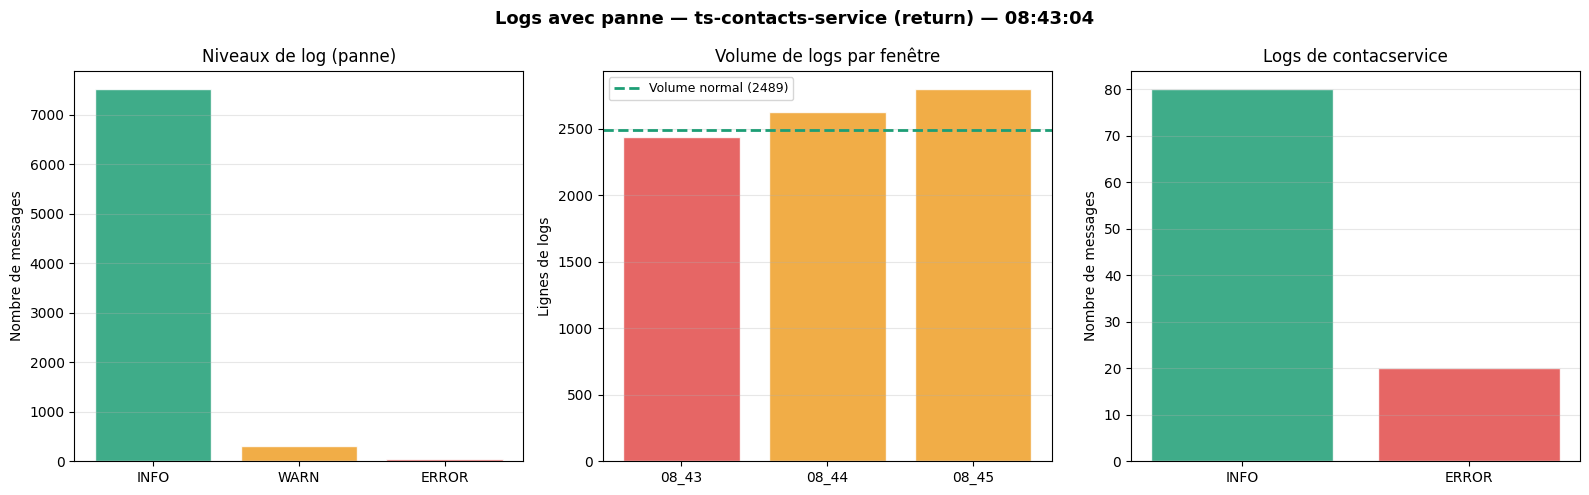

Sauvegardé : 05_logs_panne.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Logs avec panne — {premiere_panne["service"]} '
    f'({premiere_panne["fault_type"]}) — 08:43:04',
    fontsize=13, fontweight='bold'
)

# ── Graphique 1 : Niveaux de log pendant la panne
niveaux_panne = df_log_panne['niveau'].value_counts()
couleurs = {
    'INFO'   : '#1D9E75',
    'WARN'   : '#EF9F27',
    'ERROR'  : '#E24B4A',
    'INCONNU': '#888780'
}
axes[0].bar(niveaux_panne.index, niveaux_panne.values,
            color=[couleurs.get(n, '#888') for n in niveaux_panne.index],
            alpha=0.85, edgecolor='white')
axes[0].set_title('Niveaux de log (panne)')
axes[0].set_ylabel('Nombre de messages')
axes[0].grid(axis='y', alpha=0.3)

# ── Graphique 2 : Volume par fenêtre
volumes = df_log_panne['fenetre'].value_counts().sort_index()
couleurs_bar = ['#E24B4A', '#EF9F27', '#EF9F27']
axes[1].bar(volumes.index, volumes.values,
            color=couleurs_bar, alpha=0.85, edgecolor='white')
axes[1].axhline(2489, color='#1D9E75', linewidth=2,
                linestyle='--', label='Volume normal (2489)')
axes[1].set_title('Volume de logs par fenêtre')
axes[1].set_ylabel('Lignes de logs')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# ── Graphique 3 : Logs du service ciblé uniquement
logs_contacts = df_log_panne[
    df_log_panne['service'] == premiere_panne['service']
]
niveaux_contacts = logs_contacts['niveau'].value_counts()
if not niveaux_contacts.empty:
    axes[2].bar(
        niveaux_contacts.index,
        niveaux_contacts.values,
        color=[couleurs.get(n, '#888') for n in niveaux_contacts.index],
        alpha=0.85, edgecolor='white'
    )
    axes[2].set_title(f'Logs de {premiere_panne["service"].replace("ts-","").replace("-service","")}')
    axes[2].set_ylabel('Nombre de messages')
    axes[2].grid(axis='y', alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'Aucun log\npour ce service',
                 ha='center', va='center', transform=axes[2].transAxes,
                 fontsize=12, color='#888')
    axes[2].set_title(f'Logs de {premiere_panne["service"]}')

plt.tight_layout()
plt.savefig(FIGURES / '05_logs_panne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 05_logs_panne.png")

### 4.2 Métriques avec panne

On charge les métriques du pod ciblé `ts-contacts-service`  
pendant la fenêtre de panne et on compare avec la baseline normale.

Si la panne est de type `return`, on s'attend à voir :
- Un changement dans le taux de succès
- Potentiellement une variation de latence
- CPU et mémoire relativement stables

In [14]:
# Charger les métriques du service ciblé
metric_dir_panne = ANOMALIES / '2023-01-29/metric'
fichiers_panne   = sorted(metric_dir_panne.glob('*_metric.csv'))

# Trouver le fichier du service ciblé
service_cible = premiere_panne['service']
metric_file   = next(
    (f for f in fichiers_panne if service_cible in f.name), None
)

if metric_file:
    df_metric_panne = pd.read_csv(metric_file)
    df_metric_panne['datetime'] = pd.to_datetime(
        df_metric_panne['TimeStamp'], unit='s', utc=True
    )
    for col in df_metric_panne.columns:
        if col not in ['Time', 'PodName', 'datetime']:
            df_metric_panne[col] = pd.to_numeric(
                df_metric_panne[col].replace('NaN', float('nan')),
                errors='coerce'
            )
    print(f"Service  : {service_cible}")
    print(f"Lignes   : {len(df_metric_panne)}")
    print()
    cols_cles = [
        'CpuUsageRate(%)',
        'MemoryUsageRate(%)',
        'PodServerLatencyP99(s)',
        'PodSuccessRate(%)'
    ]
    print("Statistiques métriques avec panne :")
    print(df_metric_panne[cols_cles].describe().round(4).to_string())
else:
    print(f"Fichier métrique introuvable pour {service_cible}")
    print("Services disponibles :")
    for f in fichiers_panne[:10]:
        print(f"  {f.stem.rsplit('-',2)[0]}")

Service  : ts-contacts-service
Lignes   : 919

Statistiques métriques avec panne :
       CpuUsageRate(%)  MemoryUsageRate(%)  PodServerLatencyP99(s)  PodSuccessRate(%)
count         919.0000            919.0000                325.0000              919.0
mean            1.3397             22.7525                  0.0471                0.0
std             6.0855              0.3023                  0.1113                0.0
min             0.1931             21.2053                  0.0099                0.0
25%             0.5033             22.7266                  0.0247                0.0
50%             0.6841             22.8883                  0.0248                0.0
75%             1.1329             22.9310                  0.0248                0.0
max           100.0826             23.3895                  0.9900                0.0


### Visualisation des métriques avec panne

On trace les 4 métriques clés pendant la panne.  
La zone rouge indique la fenêtre d'injection (08:43 → 08:46).  
Le pic de CPU à 100% est le signal d'anomalie principal.

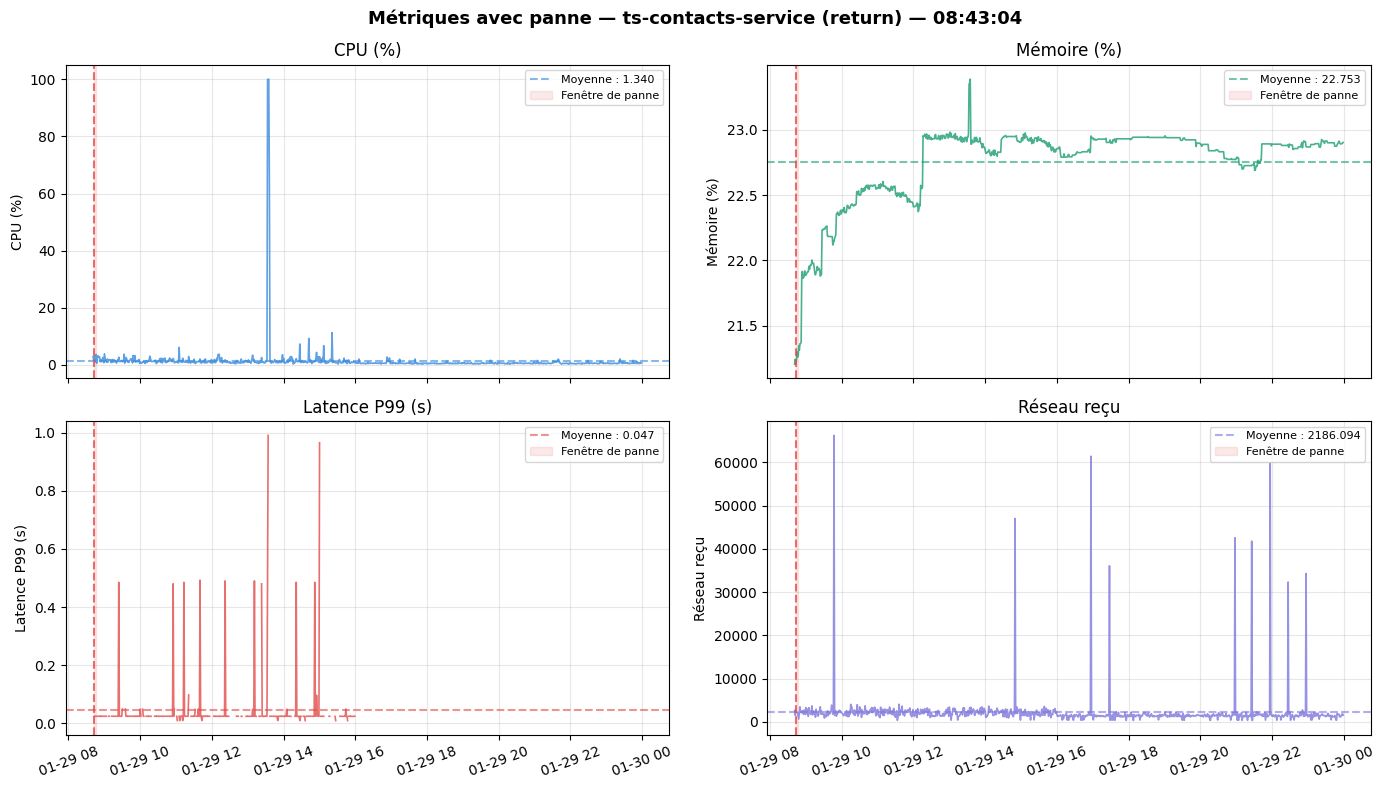

Sauvegardé : 06_metriques_panne.png


In [15]:
# Définir la fenêtre de panne
import pytz
utc = pytz.UTC
t_debut = pd.Timestamp(inject_dt).tz_localize(utc)
t_fin   = t_debut + timedelta(minutes=FAULT_DUR)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle(
    f'Métriques avec panne — {service_cible} '
    f'(return) — 08:43:04',
    fontsize=13, fontweight='bold'
)

metriques = [
    ('CpuUsageRate(%)',        'CPU (%)',           '#378ADD'),
    ('MemoryUsageRate(%)',     'Mémoire (%)',        '#1D9E75'),
    ('PodServerLatencyP99(s)', 'Latence P99 (s)',   '#E24B4A'),
    ('NetworkReceiveBytes',    'Réseau reçu',       '#7F77DD'),
]

for ax, (col, label, color) in zip(axes.flatten(), metriques):
    vals = df_metric_panne[col]
    ax.plot(df_metric_panne['datetime'], vals,
            color=color, linewidth=1.2, alpha=0.8)
    ax.axhline(vals.mean(), color=color, linewidth=1.5,
               linestyle='--', alpha=0.6,
               label=f'Moyenne : {vals.mean():.3f}')
    ax.axvspan(t_debut, t_fin,
               color='#E24B4A', alpha=0.12,
               label='Fenêtre de panne')
    ax.axvline(t_debut, color='#E24B4A',
               linewidth=1.5, linestyle='--', alpha=0.8)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[1][0].tick_params(axis='x', rotation=20)
axes[1][1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES / '06_metriques_panne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 06_metriques_panne.png")

In [16]:
# Zoom ±15 minutes autour de la panne 08:43:04
utc     = pytz.UTC
t_debut = pd.Timestamp(inject_dt).tz_localize(utc)
t_fin   = t_debut + timedelta(minutes=FAULT_DUR)

t_zoom_debut = t_debut - timedelta(minutes=15)
t_zoom_fin   = t_debut + timedelta(minutes=15)

mask_zoom = (
    (df_metric_complet['datetime'] >= t_zoom_debut) &
    (df_metric_complet['datetime'] <= t_zoom_fin)
)
df_zoom = df_metric_complet[mask_zoom]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle(
    'ZOOM — Métriques autour de la panne\n'
    'ts-contacts-service (return) — 08:43:04 ±15 min',
    fontsize=13, fontweight='bold'
)

metriques = [
    ('CpuUsageRate(%)',        'CPU (%)',           '#378ADD'),
    ('MemoryUsageRate(%)',     'Mémoire (%)',        '#1D9E75'),
    ('PodServerLatencyP99(s)', 'Latence P99 (s)',   '#E24B4A'),
    ('NetworkReceiveBytes',    'Réseau reçu',       '#7F77DD'),
]

for ax, (col, label, color) in zip(axes.flatten(), metriques):
    vals = df_zoom[col]
    ax.plot(df_zoom['datetime'], vals,
            color=color, linewidth=1.8,
            marker='o', markersize=4, alpha=0.8)
    ax.axhline(df_normal_m[col].mean(), color=color,
               linewidth=1.5, linestyle='--', alpha=0.6,
               label=f'Moyenne normale : {df_normal_m[col].mean():.3f}')
    ax.axvspan(t_debut, t_fin,
               color='#E24B4A', alpha=0.25,
               label='Fenêtre de panne (3 min)')
    ax.axvline(t_debut, color='#E24B4A',
               linewidth=2, linestyle='--', alpha=0.9)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[1][0].tick_params(axis='x', rotation=20)
axes[1][1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES / '06b_metriques_panne_zoom.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 06b_metriques_panne_zoom.png")

NameError: name 'df_metric_complet' is not defined

### 4.3 Traces avec panne

Pour une panne de type `return`, le signal principal est dans les traces.  
On s'attend à voir des spans anormaux dans `ts-contacts-service` —  
des appels qui retournent des valeurs incorrectes ou des durées inhabituelles.

In [ ]:
# Charger les traces des 3 fenêtres de panne
dfs_trace = []
for fenetre in fenetres:
    chemin = ANOMALIES / '2023-01-29/trace' / f'{fenetre}_trace.csv'
    if chemin.exists():
        df = pd.read_csv(chemin)
        df['fenetre']     = fenetre
        df['duration_ms'] = pd.to_numeric(
            df['Duration'], errors='coerce'
        ) / 1e6
        df['service'] = df['PodName'].apply(
            lambda x: str(x).rsplit('-', 2)[0]
        )
        dfs_trace.append(df)

df_trace_panne = pd.concat(dfs_trace, ignore_index=True)

print(f"Fenêtres chargées : {fenetres}")
print(f"Total spans       : {len(df_trace_panne)}")
print(f"Traces uniques    : {df_trace_panne['TraceID'].nunique()}")
print()
print("Statistiques durée (ms) — tous services :")
print(df_trace_panne['duration_ms'].describe().round(4).to_string())
print()
print("Statistiques durée (ms) — service ciblé uniquement :")
contacts = df_trace_panne[
    df_trace_panne['service'] == service_cible
]
print(contacts['duration_ms'].describe().round(4).to_string())

Fenêtres chargées : ['08_43', '08_44', '08_45']
Total spans       : 14460
Traces uniques    : 169

Statistiques durée (ms) — tous services :
count    14460.0000
mean         0.0237
std          0.0838
min          0.0000
25%          0.0010
50%          0.0028
75%          0.0099
max          2.3780

Statistiques durée (ms) — service ciblé uniquement :
count    150.0000
mean       0.0055
std        0.0045
min        0.0009
25%        0.0013
50%        0.0046
75%        0.0093
max        0.0170


### Visualisation des traces avec panne

On compare le volume et les durées des spans  
entre la phase normale et la phase de panne.

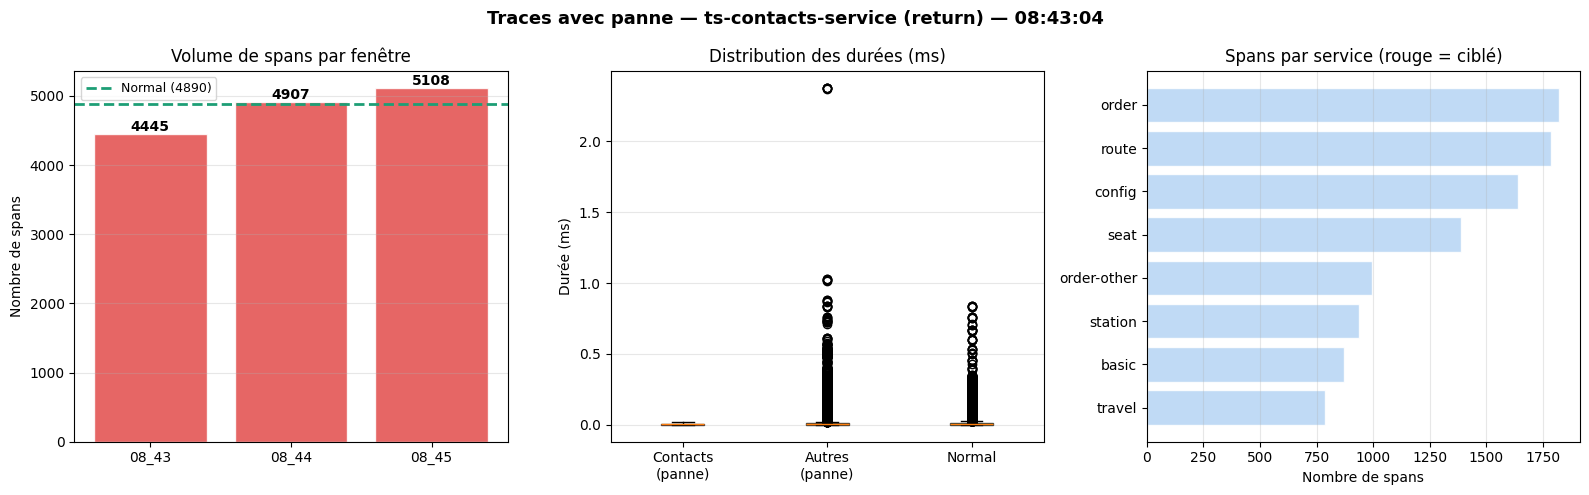

Sauvegardé : 07_traces_panne.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Traces avec panne — {service_cible} '
    f'(return) — 08:43:04',
    fontsize=13, fontweight='bold'
)

# ── Graphique 1 : Volume de spans par fenêtre
volumes = df_trace_panne['fenetre'].value_counts().sort_index()
axes[0].bar(volumes.index, volumes.values,
            color='#E24B4A', alpha=0.85, edgecolor='white')
axes[0].axhline(4890, color='#1D9E75', linewidth=2,
                linestyle='--', label='Normal (4890)')
axes[0].set_title('Volume de spans par fenêtre')
axes[0].set_ylabel('Nombre de spans')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(volumes.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# ── Graphique 2 : Durée des spans — service ciblé vs autres
autres = df_trace_panne[df_trace_panne['service'] != service_cible]
data_box = [
    contacts['duration_ms'].dropna().values,
    autres['duration_ms'].dropna().values,
    df_trace_norm['duration_ms'].dropna().values
]
labels_box = ['Contacts\n(panne)', 'Autres\n(panne)', 'Normal']
bp = axes[1].boxplot(data_box, labels=labels_box, patch_artist=True)
couleurs_box = ['#E24B4A', '#EF9F27', '#1D9E75']
for patch, color in zip(bp['boxes'], couleurs_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribution des durées (ms)')
axes[1].set_ylabel('Durée (ms)')
axes[1].grid(axis='y', alpha=0.3)

# ── Graphique 3 : Top services pendant la panne
top_svcs  = df_trace_panne['service'].value_counts().head(8)
noms      = [s.replace('ts-','').replace('-service','')
             for s in top_svcs.index]
colors_bar = ['#E24B4A' if s == service_cible else '#B5D4F4'
              for s in top_svcs.index]
axes[2].barh(noms[::-1], top_svcs.values[::-1],
             color=colors_bar[::-1], alpha=0.85, edgecolor='white')
axes[2].set_title('Spans par service (rouge = ciblé)')
axes[2].set_xlabel('Nombre de spans')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '07_traces_panne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 07_traces_panne.png")

In [ ]:
# Charger les métriques NORMALES du service ciblé (ts-contacts-service)
metric_dir_norm = NORMAL / '2023-01-29/metric'
fichiers_norm   = sorted(metric_dir_norm.glob('*_metric.csv'))

# Trouver ts-contacts-service dans les données normales
metric_norm_contacts = next(
    (f for f in fichiers_norm if service_cible in f.name), None
)

if metric_norm_contacts:
    df_metric_norm_contacts = pd.read_csv(metric_norm_contacts)
    df_metric_norm_contacts['datetime'] = pd.to_datetime(
        df_metric_norm_contacts['TimeStamp'], unit='s', utc=True
    )
    for col in df_metric_norm_contacts.columns:
        if col not in ['Time', 'PodName', 'datetime']:
            df_metric_norm_contacts[col] = pd.to_numeric(
                df_metric_norm_contacts[col].replace('NaN', float('nan')),
                errors='coerce'
            )
    print(f"✓ Métriques normales trouvées : {metric_norm_contacts.name}")
    print(f"  Lignes : {len(df_metric_norm_contacts)}")
    print()
    print("CPU normal de ts-contacts-service :")
    print(df_metric_norm_contacts['CpuUsageRate(%)'].describe().round(4).to_string())
else:
    print(f"✗ Métriques normales introuvables pour {service_cible}")
    print("Services disponibles :")
    for f in fichiers_norm[:10]:
        print(f"  {f.stem.rsplit('-',2)[0]}")

✓ Métriques normales trouvées : ts-contacts-service-866bd68c97-xcqfx_metric.csv
  Lignes : 919

CPU normal de ts-contacts-service :
count    919.0000
mean       1.3397
std        6.0855
min        0.1931
25%        0.5033
50%        0.6841
75%        1.1329
max      100.0826


## 5. Comparaison normal vs anormal

On place côte à côte les données normales et les données avec panne  
pour visualiser clairement les signaux d'anomalie.

Cette comparaison est le cœur de notre analyse —  
c'est ce que nos algorithmes de détection devront reproduire automatiquement.

On compare 3 dimensions :
- Volume et niveaux des logs
- Métriques CPU et latence
- Volume et durée des traces

✓ Points normaux : 907
✓ Points panne   : 12


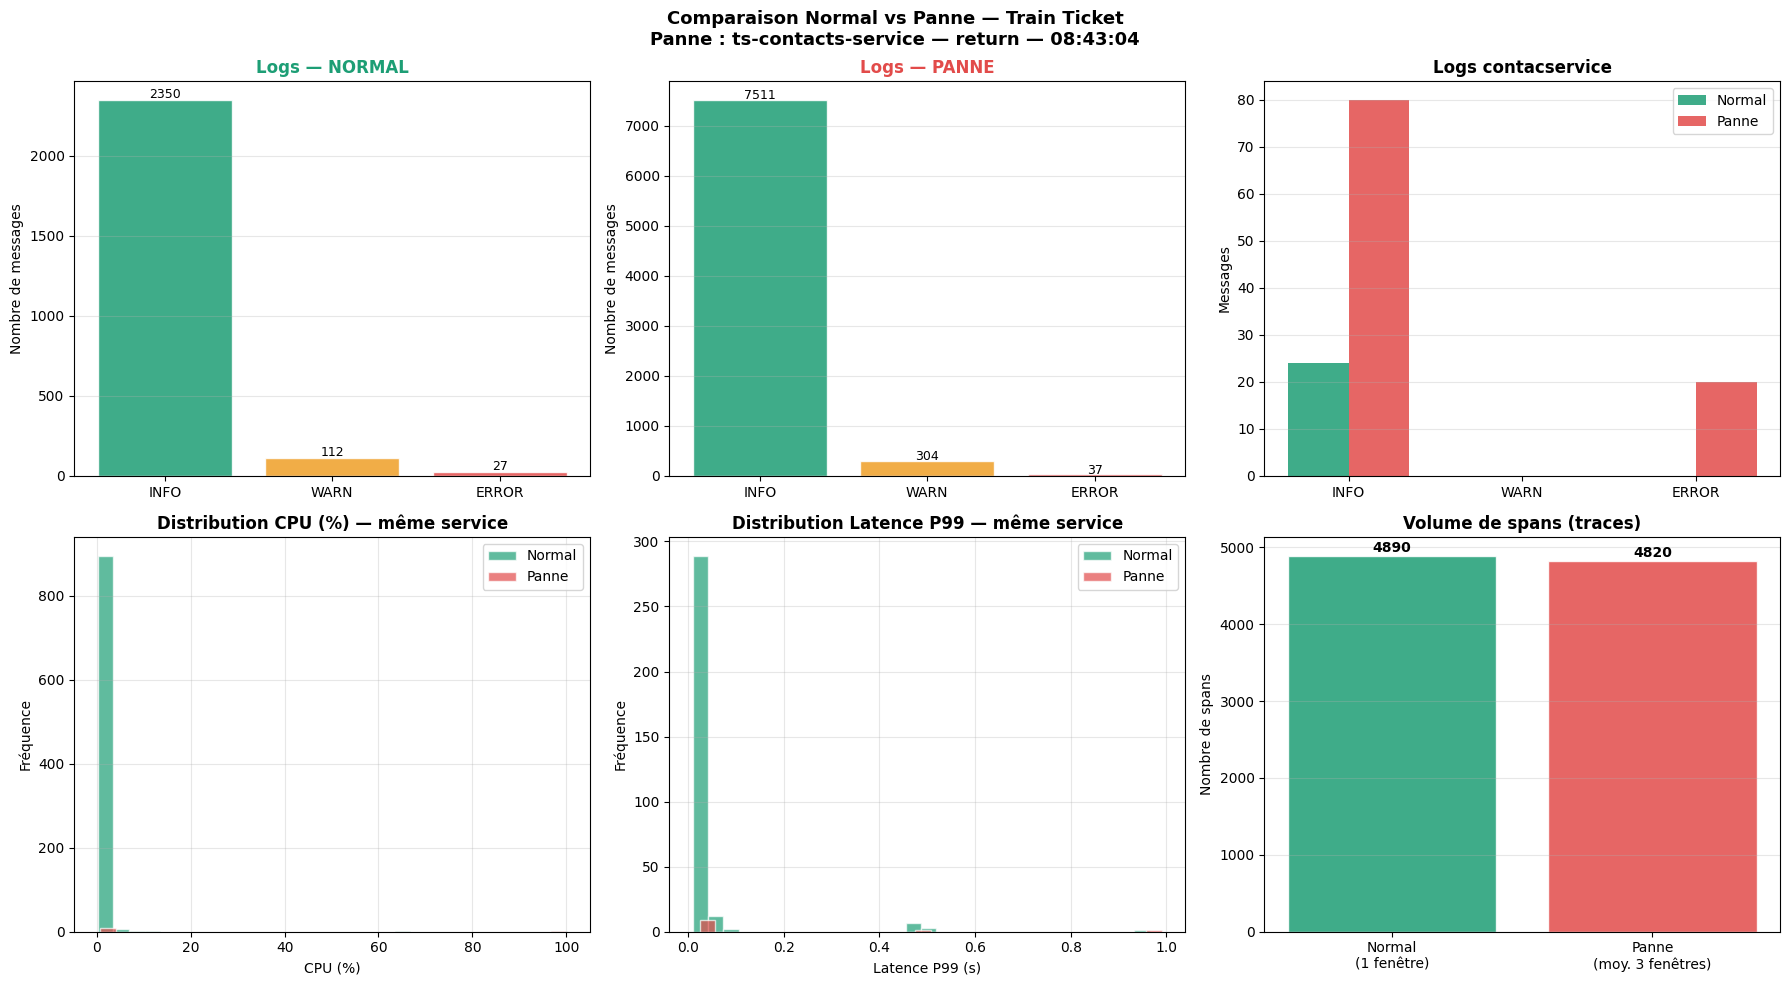

Sauvegardé : 08_comparaison_normal_panne.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Comparaison Normal vs Panne — Train Ticket\n'
    f'Panne : {service_cible} — {premiere_panne["fault_type"]} — 08:43:04',
    fontsize=13, fontweight='bold'
)

# ══ LIGNE 1 : LOGS ══

# Graphique 1 : Niveaux logs normal
niveaux_norm = df_log_normal['niveau'].value_counts()
couleurs_niv = {
    'INFO'   : '#1D9E75',
    'WARN'   : '#EF9F27',
    'ERROR'  : '#E24B4A',
    'INCONNU': '#888780'
}
axes[0,0].bar(
    niveaux_norm.index, niveaux_norm.values,
    color=[couleurs_niv.get(n,'#888') for n in niveaux_norm.index],
    alpha=0.85, edgecolor='white'
)
axes[0,0].set_title('Logs — NORMAL', fontweight='bold', color='#1D9E75')
axes[0,0].set_ylabel('Nombre de messages')
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(niveaux_norm.values):
    axes[0,0].text(i, v + 10, str(v), ha='center', fontsize=9)

# Graphique 2 : Niveaux logs panne
niveaux_pan = df_log_panne['niveau'].value_counts()
axes[0,1].bar(
    niveaux_pan.index, niveaux_pan.values,
    color=[couleurs_niv.get(n,'#888') for n in niveaux_pan.index],
    alpha=0.85, edgecolor='white'
)
axes[0,1].set_title('Logs — PANNE', fontweight='bold', color='#E24B4A')
axes[0,1].set_ylabel('Nombre de messages')
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(niveaux_pan.values):
    axes[0,1].text(i, v + 10, str(v), ha='center', fontsize=9)

# Graphique 3 : Logs service ciblé normal vs panne
logs_contacts_norm = df_log_normal[
    df_log_normal['service'] == service_cible
]['niveau'].value_counts()
logs_contacts_pan = df_log_panne[
    df_log_panne['service'] == service_cible
]['niveau'].value_counts()

x     = range(3)
width = 0.35
niveaux_labels = ['INFO', 'WARN', 'ERROR']
axes[0,2].bar(
    [i - width/2 for i in x],
    [logs_contacts_norm.get(n, 0) for n in niveaux_labels],
    width, label='Normal', color='#1D9E75', alpha=0.85
)
axes[0,2].bar(
    [i + width/2 for i in x],
    [logs_contacts_pan.get(n, 0) for n in niveaux_labels],
    width, label='Panne', color='#E24B4A', alpha=0.85
)
axes[0,2].set_title(
    f'Logs {service_cible.replace("ts-","").replace("-service","")}',
    fontweight='bold'
)
axes[0,2].set_xticks(list(x))
axes[0,2].set_xticklabels(niveaux_labels)
axes[0,2].set_ylabel('Messages')
axes[0,2].legend()
axes[0,2].grid(axis='y', alpha=0.3)

# ══ LIGNE 2 : MÉTRIQUES + TRACES ══

# Graphique 4 : CPU normal vs panne (même service)
# Séparer les métriques normales et anormales du même service
df_metric_complet = pd.read_csv(metric_file)
df_metric_complet['datetime'] = pd.to_datetime(
    df_metric_complet['TimeStamp'], unit='s', utc=True
)
for col in df_metric_complet.columns:
    if col not in ['Time', 'PodName', 'datetime']:
        df_metric_complet[col] = pd.to_numeric(
            df_metric_complet[col].replace('NaN', float('nan')),
            errors='coerce'
        )

# Pannes sur ce service
pannes_contacts = faults[faults['service'] == service_cible]

# Fonction qui dit si un timestamp est pendant une panne
def est_en_panne(dt):
    for _, panne in pannes_contacts.iterrows():
        debut = pd.Timestamp(panne['inject_dt']).tz_localize('UTC')
        fin   = debut + timedelta(minutes=FAULT_DUR)
        if debut <= dt <= fin:
            return True
    return False

# Appliquer le masque
df_metric_complet['en_panne'] = df_metric_complet['datetime'].apply(
    est_en_panne
)

# Créer les deux sous-ensembles
df_normal_m = df_metric_complet[df_metric_complet['en_panne'] == False]
df_panne_m  = df_metric_complet[df_metric_complet['en_panne'] == True]

print(f"✓ Points normaux : {len(df_normal_m)}")
print(f"✓ Points panne   : {len(df_panne_m)}")
axes[1,0].hist(
    df_normal_m['CpuUsageRate(%)'].dropna(),
    bins=30, color='#1D9E75', alpha=0.7,
    label='Normal', edgecolor='white'
)
axes[1,0].hist(
    df_panne_m['CpuUsageRate(%)'].dropna(),
    bins=30, color='#E24B4A', alpha=0.7,
    label='Panne', edgecolor='white'
)
axes[1,0].set_title('Distribution CPU (%) — même service', fontweight='bold')
axes[1,0].set_xlabel('CPU (%)')
axes[1,0].set_ylabel('Fréquence')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Graphique 5 : Latence P99 normal vs panne (même service)
axes[1,1].hist(
    df_normal_m['PodServerLatencyP99(s)'].dropna(),
    bins=30, color='#1D9E75', alpha=0.7,
    label='Normal', edgecolor='white'
)
axes[1,1].hist(
    df_panne_m['PodServerLatencyP99(s)'].dropna(),
    bins=30, color='#E24B4A', alpha=0.7,
    label='Panne', edgecolor='white'
)
axes[1,1].set_title('Distribution Latence P99 — même service', fontweight='bold')
axes[1,1].set_xlabel('Latence P99 (s)')
axes[1,1].set_ylabel('Fréquence')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

# Graphique 6 : Volume traces normal vs panne
categories = ['Normal\n(1 fenêtre)', 'Panne\n(moy. 3 fenêtres)']
volumes    = [len(df_trace_norm), len(df_trace_panne) / 3]
colors_vol = ['#1D9E75', '#E24B4A']
bars = axes[1,2].bar(
    categories, volumes,
    color=colors_vol, alpha=0.85, edgecolor='white'
)
axes[1,2].set_title('Volume de spans (traces)', fontweight='bold')
axes[1,2].set_ylabel('Nombre de spans')
axes[1,2].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, volumes):
    axes[1,2].text(
        bar.get_x() + bar.get_width()/2,
        v + 50, f'{v:.0f}',
        ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig(FIGURES / '08_comparaison_normal_panne.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 08_comparaison_normal_panne.png")

In [ ]:
# Comparer les chemins des deux fichiers
import os

f_normal = metric_norm_contacts
f_panne  = metric_file

print(f"Fichier normal : {f_normal}")
print(f"Fichier panne  : {f_panne}")
print()

# Vérifier si ce sont les mêmes données
df_n = pd.read_csv(f_normal)
df_p = pd.read_csv(f_panne)

print(f"Normal — premier timestamp : {df_n['TimeStamp'].iloc[0]}")
print(f"Panne  — premier timestamp : {df_p['TimeStamp'].iloc[0]}")
print()
print(f"Fichiers identiques : {df_n.equals(df_p)}")

Fichier normal : /home/eunice/Bureau/Train_ticket/projet/data/normal/2023-01-29/metric/ts-contacts-service-866bd68c97-xcqfx_metric.csv
Fichier panne  : /home/eunice/Bureau/Train_ticket/projet/data/anomalies/2023-01-29/metric/ts-contacts-service-866bd68c97-xcqfx_metric.csv

Normal — premier timestamp : 1674981669
Panne  — premier timestamp : 1674981669

Fichiers identiques : True
